In [1]:
import numpy as np

import cv2

import matplotlib.pyplot as plt

from PIL import Image

import warnings
warnings.filterwarnings('ignore')

In [16]:
#Görüntü oluşturma
siyah_goruntu = np.zeros((300, 300, 3), dtype=np.uint8)

print(f"Görüntü şekli: {siyah_goruntu.shape}")
print(f"Veri tipi: {siyah_goruntu.dtype}")
print(f"Min değer: {siyah_goruntu.min()}")
print(f"Max değer: {siyah_goruntu.max()}")


Görüntü şekli: (300, 300, 3)
Veri tipi: uint8
Min değer: 0
Max değer: 0


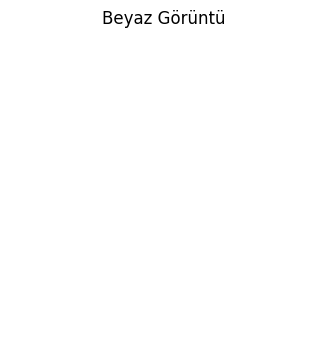

In [3]:
#Beyaz oluşturduk
beyaz_goruntu = np.full((300, 300, 3), 255, dtype=np.uint8)

plt.figure(figsize=(4, 4))
plt.imshow(beyaz_goruntu)
plt.title("Beyaz Görüntü")
plt.axis('off')
plt.show()


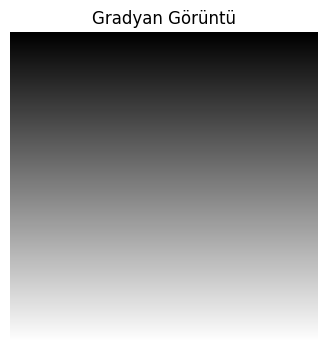

In [4]:
#Gradyan görüntü oluşturduk
gradyan = np.zeros((300, 300, 3), dtype=np.uint8)

for i in range(300):
    deger = int((i / 300) * 255)
    gradyan[i, :] = [deger, deger, deger]

plt.figure(figsize=(4, 4))
plt.imshow(gradyan)
plt.title("Gradyan Görüntü")
plt.axis('off')
plt.show()

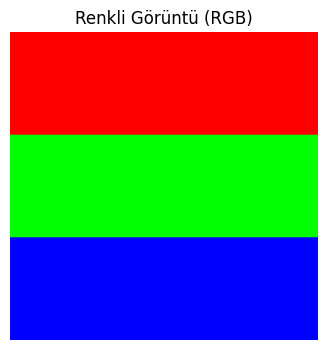

In [5]:
#Renkli görüntü oluşturduk
renkli = np.zeros((300, 300, 3), dtype=np.uint8)

renkli[0:100, :, 2] = 255
renkli[100:200, :, 1] = 255
renkli[200:300, :, 0] = 255

renkli_rgb = cv2.cvtColor(renkli, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4, 4))
plt.imshow(renkli_rgb)
plt.title("Renkli Görüntü (RGB)")
plt.axis('off')
plt.show()

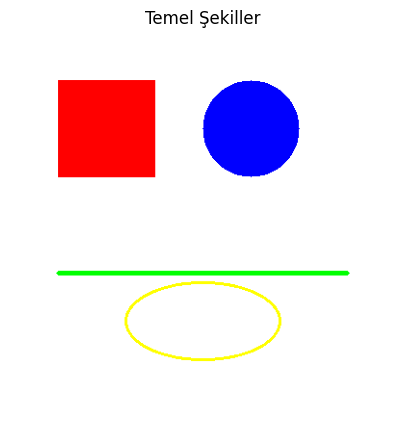

In [6]:
#Temel şekil çizme
seker = np.full((400, 400, 3), 255, dtype=np.uint8)

cv2.rectangle(seker, (50, 50), (150, 150), (0, 0, 255), -1)

cv2.circle(seker, (250, 100), 50, (255, 0, 0), -1)

cv2.line(seker, (50, 250), (350, 250), (0, 255, 0), 3)

cv2.ellipse(seker, (200, 300), (80, 40), 0, 0, 360, (0, 255, 255), 2)

seker_rgb = cv2.cvtColor(seker, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(seker_rgb)
plt.title("Temel Şekiller")
plt.axis('off')
plt.show()


Orijinal boyut: (400, 400, 3)
Küçültülmüş boyut: (200, 200, 3)


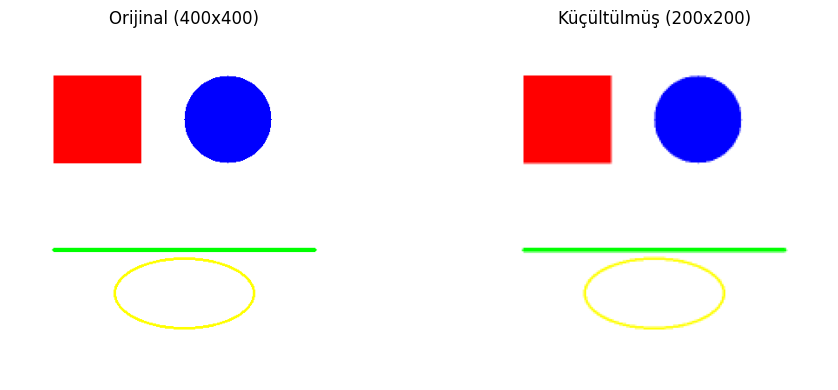

In [7]:
#Görüntü boyutu değiştirme
kucuk_goruntu = cv2.resize(seker, (200, 200))

print(f"Orijinal boyut: {seker.shape}")
print(f"Küçültülmüş boyut: {kucuk_goruntu.shape}")

fig, akslar = plt.subplots(1, 2, figsize=(10, 4))

akslar[0].imshow(cv2.cvtColor(seker, cv2.COLOR_BGR2RGB))
akslar[0].set_title("Orijinal (400x400)")
akslar[0].axis('off')

akslar[1].imshow(cv2.cvtColor(kucuk_goruntu, cv2.COLOR_BGR2RGB))
akslar[1].set_title("Küçültülmüş (200x200)")
akslar[1].axis('off')

plt.tight_layout()
plt.show()


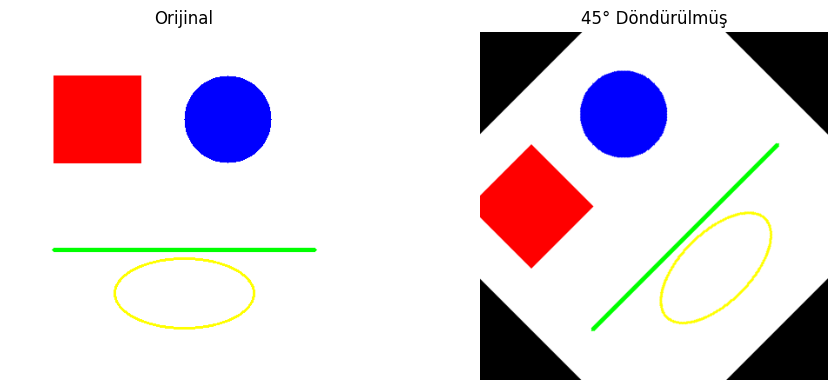

In [8]:
#Görüntü döndürme
merkez = (seker.shape[1] // 2, seker.shape[0] // 2)
donustur_matrisi = cv2.getRotationMatrix2D(merkez, 45, 1)

donmis_goruntu = cv2.warpAffine(
    seker,
    donustur_matrisi,
    (seker.shape[1], seker.shape[0])
)

fig, akslar = plt.subplots(1, 2, figsize=(10, 4))

akslar[0].imshow(cv2.cvtColor(seker, cv2.COLOR_BGR2RGB))
akslar[0].set_title("Orijinal")
akslar[0].axis('off')

akslar[1].imshow(cv2.cvtColor(donmis_goruntu, cv2.COLOR_BGR2RGB))
akslar[1].set_title("45° Döndürülmüş")
akslar[1].axis('off')

plt.tight_layout()
plt.show()

Renkli görüntü şekli: (400, 400, 3)
Gri görüntü şekli: (400, 400)


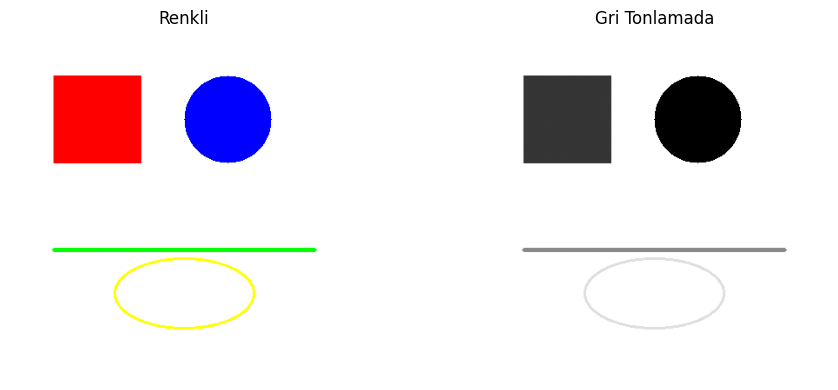

In [9]:
#Görüntüyü gri tonlamaya çevirme
gri_goruntu = cv2.cvtColor(seker, cv2.COLOR_BGR2GRAY)

print(f"Renkli görüntü şekli: {seker.shape}")
print(f"Gri görüntü şekli: {gri_goruntu.shape}")

fig, akslar = plt.subplots(1, 2, figsize=(10, 4))

akslar[0].imshow(cv2.cvtColor(seker, cv2.COLOR_BGR2RGB))
akslar[0].set_title("Renkli")
akslar[0].axis('off')

akslar[1].imshow(gri_goruntu, cmap='gray')
akslar[1].set_title("Gri Tonlamada")
akslar[1].axis('off')

plt.tight_layout()
plt.show()


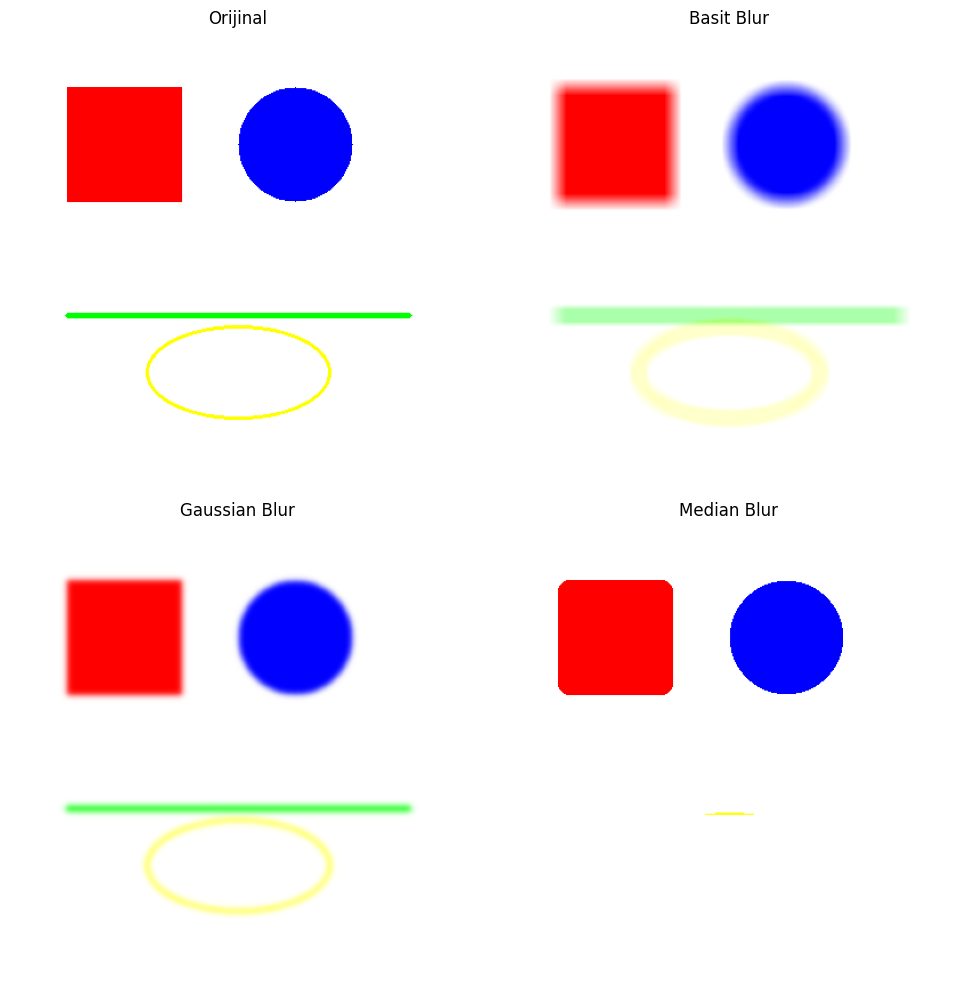

In [10]:
#Bulanıklaştırma
bulanık = cv2.blur(seker, (15, 15))

gaussian_bulanık = cv2.GaussianBlur(seker, (15, 15), 0)

median_bulanık = cv2.medianBlur(seker, 15)

fig, akslar = plt.subplots(2, 2, figsize=(10, 10))

akslar[0, 0].imshow(cv2.cvtColor(seker, cv2.COLOR_BGR2RGB))
akslar[0, 0].set_title("Orijinal")
akslar[0, 0].axis('off')

akslar[0, 1].imshow(cv2.cvtColor(bulanık, cv2.COLOR_BGR2RGB))
akslar[0, 1].set_title("Basit Blur")
akslar[0, 1].axis('off')

akslar[1, 0].imshow(cv2.cvtColor(gaussian_bulanık, cv2.COLOR_BGR2RGB))
akslar[1, 0].set_title("Gaussian Blur")
akslar[1, 0].axis('off')

akslar[1, 1].imshow(cv2.cvtColor(median_bulanık, cv2.COLOR_BGR2RGB))
akslar[1, 1].set_title("Median Blur")
akslar[1, 1].axis('off')

plt.tight_layout()
plt.show()

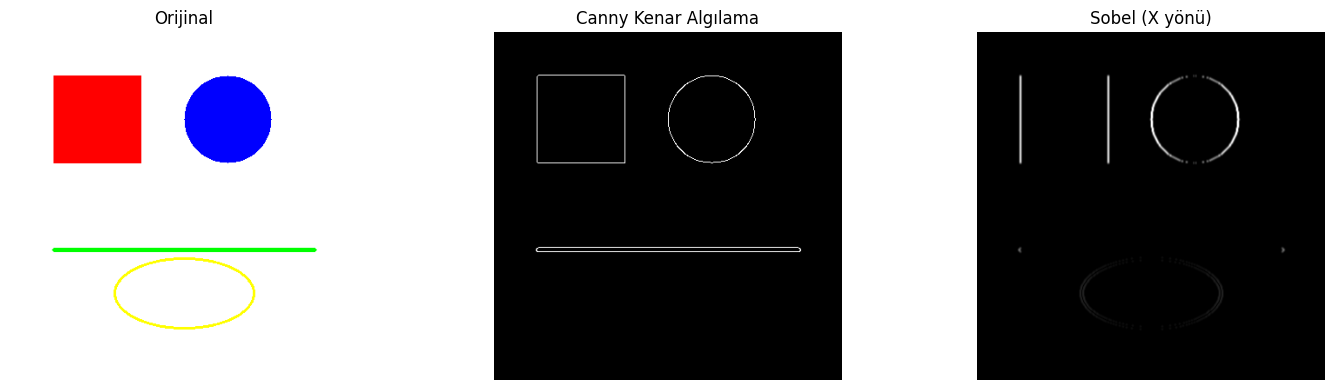

In [11]:
#Kenar algılama
gri = cv2.cvtColor(seker, cv2.COLOR_BGR2GRAY)

kenarlı_canny = cv2.Canny(gri, 100, 200)

sobel_x = cv2.Sobel(gri, cv2.CV_64F, 1, 0, ksize=5)
sobel_x = np.absolute(sobel_x)
sobel_x = np.uint8(255 * sobel_x / np.max(sobel_x))

fig, akslar = plt.subplots(1, 3, figsize=(15, 4))

akslar[0].imshow(cv2.cvtColor(seker, cv2.COLOR_BGR2RGB))
akslar[0].set_title("Orijinal")
akslar[0].axis('off')

akslar[1].imshow(kenarlı_canny, cmap='gray')
akslar[1].set_title("Canny Kenar Algılama")
akslar[1].axis('off')

akslar[2].imshow(sobel_x, cmap='gray')
akslar[2].set_title("Sobel (X yönü)")
akslar[2].axis('off')

plt.tight_layout()
plt.show()

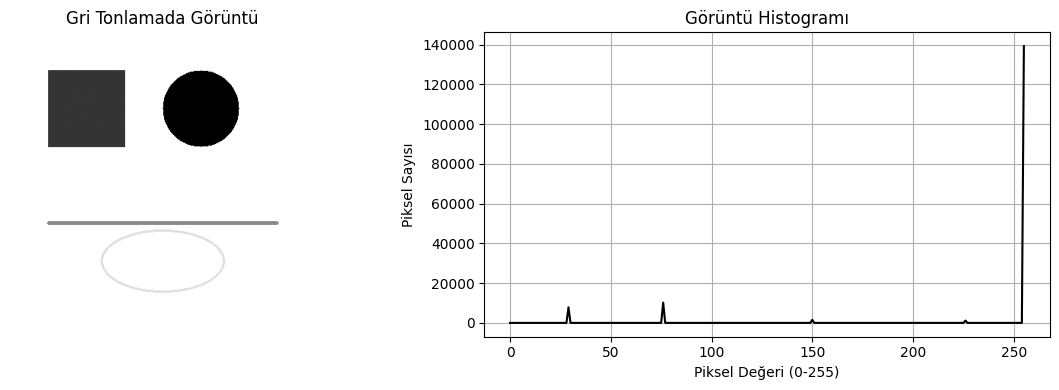

Histogramın şekli: (256,)
Toplam piksel sayısı: 160000.0


In [12]:
#Görüntünün histogramı
gri = cv2.cvtColor(seker, cv2.COLOR_BGR2GRAY)

histogram = cv2.calcHist([gri], [0], None, [256], [0, 256])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.imshow(gri, cmap='gray')
ax1.set_title("Gri Tonlamada Görüntü")
ax1.axis('off')

ax2.plot(histogram, color='black')
ax2.set_title("Görüntü Histogramı")
ax2.set_xlabel("Piksel Değeri (0-255)")
ax2.set_ylabel("Piksel Sayısı")
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Histogramın şekli: {histogram.shape}")
print(f"Toplam piksel sayısı: {np.sum(histogram)}")


Manuel eşik: 127.0
Otsu tarafından belirlenen eşik: 150.0


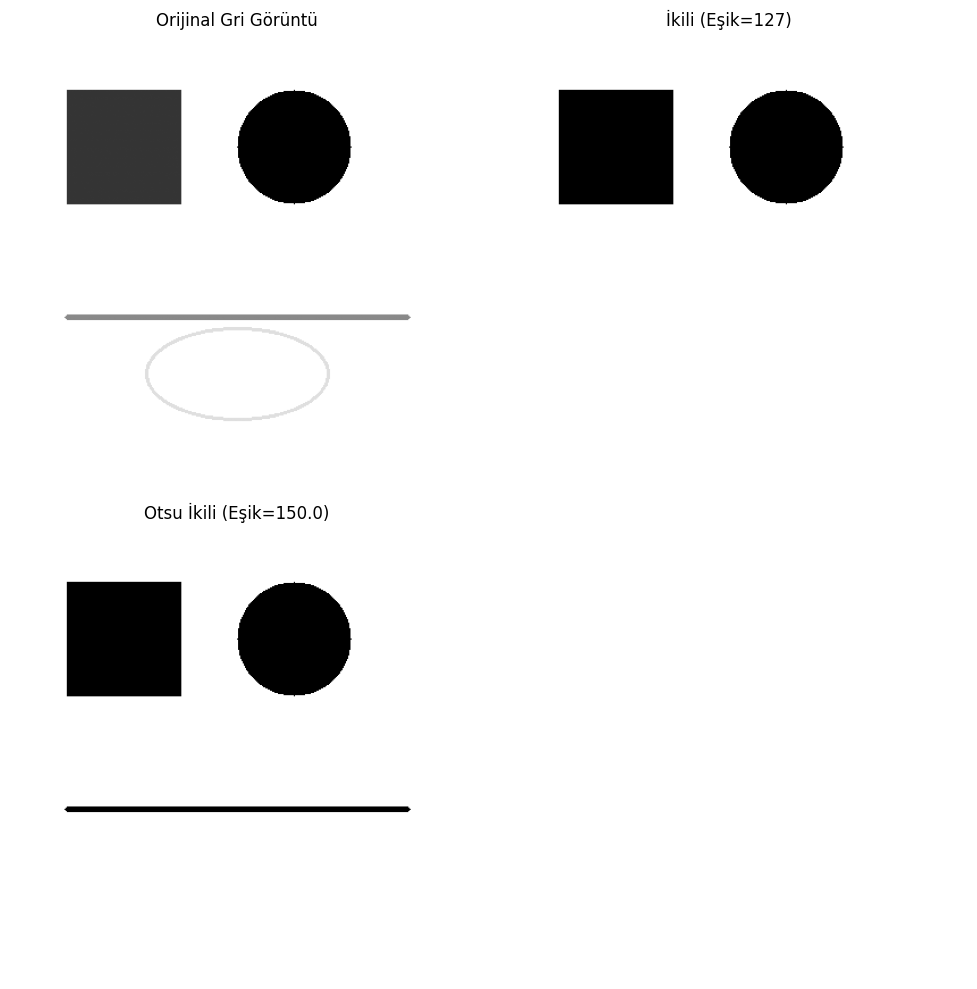

In [13]:
#Eşik belirleme
gri = cv2.cvtColor(seker, cv2.COLOR_BGR2GRAY)

ret, ikili = cv2.threshold(gri, 127, 255, cv2.THRESH_BINARY)

ret_otsu, ikili_otsu = cv2.threshold(
    gri, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print(f"Manuel eşik: {ret}")
print(f"Otsu tarafından belirlenen eşik: {ret_otsu}")

fig, akslar = plt.subplots(2, 2, figsize=(10, 10))

akslar[0, 0].imshow(gri, cmap='gray')
akslar[0, 0].set_title("Orijinal Gri Görüntü")
akslar[0, 0].axis('off')

akslar[0, 1].imshow(ikili, cmap='gray')
akslar[0, 1].set_title("İkili (Eşik=127)")
akslar[0, 1].axis('off')

akslar[1, 0].imshow(ikili_otsu, cmap='gray')
akslar[1, 0].set_title(f"Otsu İkili (Eşik={ret_otsu})")
akslar[1, 0].axis('off')

akslar[1, 1].axis('off')

plt.tight_layout()
plt.show()

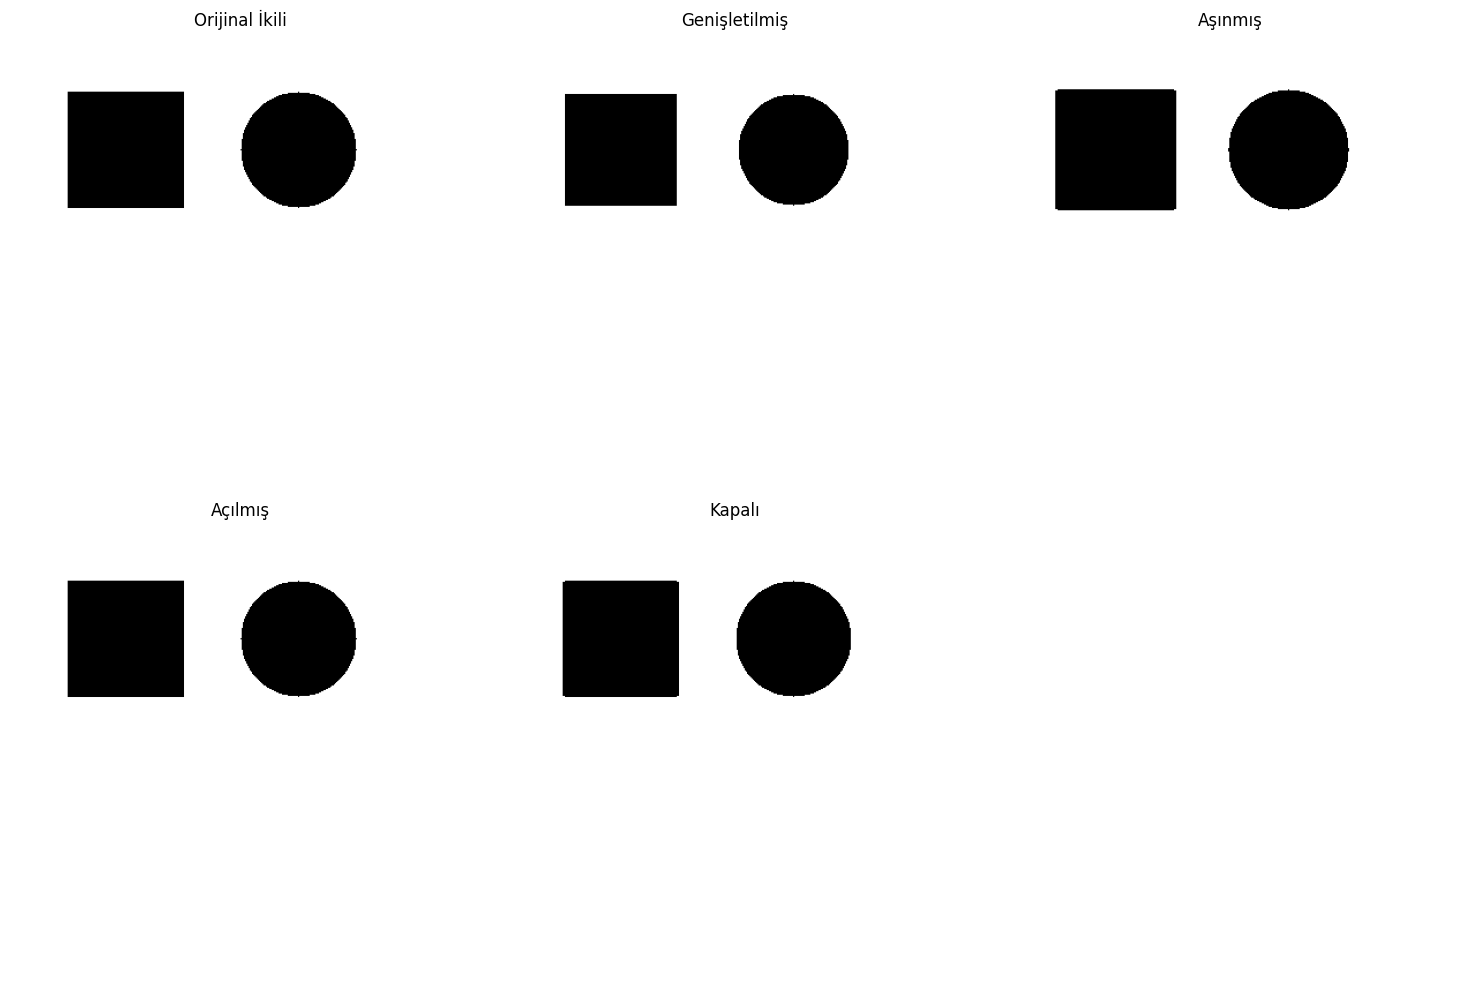

In [14]:
#Morfolojik işlemler
gri = cv2.cvtColor(seker, cv2.COLOR_BGR2GRAY)
ret, ikili = cv2.threshold(gri, 127, 255, cv2.THRESH_BINARY)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

genisletilmis = cv2.dilate(ikili, kernel, iterations=1)

asinmis = cv2.erode(ikili, kernel, iterations=1)

acilmis = cv2.morphologyEx(ikili, cv2.MORPH_OPEN, kernel)

kapanmis = cv2.morphologyEx(ikili, cv2.MORPH_CLOSE, kernel)

fig, akslar = plt.subplots(2, 3, figsize=(15, 10))

akslar[0, 0].imshow(ikili, cmap='gray')
akslar[0, 0].set_title("Orijinal İkili")
akslar[0, 0].axis('off')

akslar[0, 1].imshow(genisletilmis, cmap='gray')
akslar[0, 1].set_title("Genişletilmiş")
akslar[0, 1].axis('off')

akslar[0, 2].imshow(asinmis, cmap='gray')
akslar[0, 2].set_title("Aşınmış")
akslar[0, 2].axis('off')

akslar[1, 0].imshow(acilmis, cmap='gray')
akslar[1, 0].set_title("Açılmış")
akslar[1, 0].axis('off')

akslar[1, 1].imshow(kapanmis, cmap='gray')
akslar[1, 1].set_title("Kapalı")
akslar[1, 1].axis('off')

akslar[1, 2].axis('off')

plt.tight_layout()
plt.show()

Bulunan kontur sayısı: 3


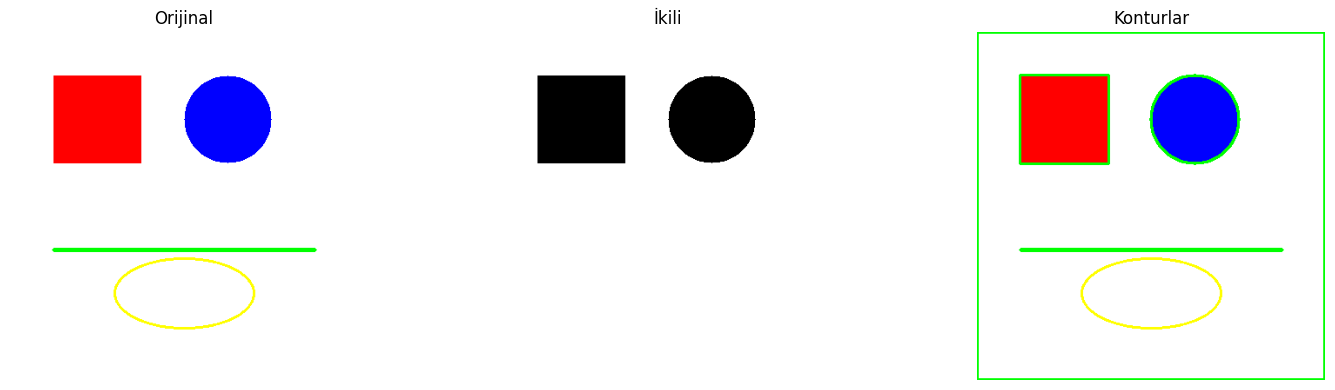

Kontur 0: Alan=159201.00, Çevre=1596.00
Kontur 1: Alan=7986.00, Çevre=335.36
Kontur 2: Alan=10402.00, Çevre=405.66


In [15]:
#Kontur agılama
gri = cv2.cvtColor(seker, cv2.COLOR_BGR2GRAY)
ret, ikili = cv2.threshold(gri, 127, 255, cv2.THRESH_BINARY)

konturs, hierarchy = cv2.findContours(
    ikili,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE
)

print(f"Bulunan kontur sayısı: {len(konturs)}")

kontur_goruntu = seker.copy()

cv2.drawContours(kontur_goruntu, konturs, -1, (0, 255, 0), 2)

fig, akslar = plt.subplots(1, 3, figsize=(15, 4))

akslar[0].imshow(cv2.cvtColor(seker, cv2.COLOR_BGR2RGB))
akslar[0].set_title("Orijinal")
akslar[0].axis('off')

akslar[1].imshow(ikili, cmap='gray')
akslar[1].set_title("İkili")
akslar[1].axis('off')

akslar[2].imshow(cv2.cvtColor(kontur_goruntu, cv2.COLOR_BGR2RGB))
akslar[2].set_title("Konturlar")
akslar[2].axis('off')

plt.tight_layout()
plt.show()

for i, kontur in enumerate(konturs):
    alan = cv2.contourArea(kontur)
    cevre = cv2.arcLength(kontur, True)
    print(f"Kontur {i}: Alan={alan:.2f}, Çevre={cevre:.2f}")
